In [1]:
import sys
sys.path.append('../')

import numpy as np
import torch
import matplotlib.pyplot as plt
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from data_loader import PairData
from env_v2_07 import PairTradingEnv
from ddqn import DoubleDQN

SEED = 42
rng  = np.random.default_rng(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [2]:
# ── Data & cointegration ─────────────────────────────────────────────────
# Mirrors the original ZC/ZW notebook:
#   beta     — Johansen on Q1 (avoids food-crisis spike)
#   intercept/std — calibrated on Q3 only (middle quarter, stable period)
#   train    — [0, q4)   test — [q4, N)

data   = PairData('../../data/real_pair_ZC_ZW.csv')
prices = data.s
N      = prices.shape[1]

q1        = N // 4
q3        = N // 2
train_end = 3 * N // 4   # called q4 in original notebook

log_A = np.log(prices[0])   # ZC (corn)
log_B = np.log(prices[1])   # ZW (wheat)

# Johansen on first quarter only
jres      = coint_johansen(np.column_stack([log_A[:q1], log_B[:q1]]), det_order=0, k_ar_diff=1)
cv        = jres.evec[:, 0]
beta      = float(-cv[1] / cv[0])

# Intercept + std from Q3 (avoids food-crisis distortion)
spread_q3 = log_A[q3:train_end] - beta * log_B[q3:train_end]
intercept  = float(spread_q3.mean())
train_mean = 0.0                         # intercept already centres Q3 spread
train_std  = float(spread_q3.std())      # scale from the stable Q3 window

print(f'N={N}  |  q1={q1}  q3={q3}  train_end={train_end}  test_end={N}')
print(f'beta={beta:.4f}  intercept={intercept:.4f}  (Johansen on Q1, scale from Q3)')
print(f'train_std={train_std:.4f}')

# Sanity: full training spread
hist_spread = log_A[:train_end] - beta * log_B[:train_end] - intercept
print(f'Full train spread  mean={hist_spread.mean():.4f}  std={hist_spread.std():.4f}')

N=5029  |  q1=1257  q3=2514  train_end=3771  test_end=5029
beta=2.0433  intercept=-6.7315  (Johansen on Q1, scale from Q3)
train_std=0.2110
Full train spread  mean=-0.1605  std=0.3038


In [3]:
# ── Episode setup — real windows only ────────────────────────────────────
EPISODE_LEN = 1000
EP_LEN_FULL = 3 + EPISODE_LEN   # 1003: 3-step vel warmup + 1000 tradeable steps

REAL_T_MAX = train_end - EP_LEN_FULL   # latest valid start index

def sample_real(t0):
    return prices[:, t0 : t0 + EP_LEN_FULL]

print(f'Episode length: {EPISODE_LEN} steps  |  total slice: {EP_LEN_FULL} pts')
print(f'Real episode start range: [0, {REAL_T_MAX}]  ({REAL_T_MAX+1} options)')

Episode length: 1000 steps  |  total slice: 1003 pts
Real episode start range: [0, 2768]  (2769 options)


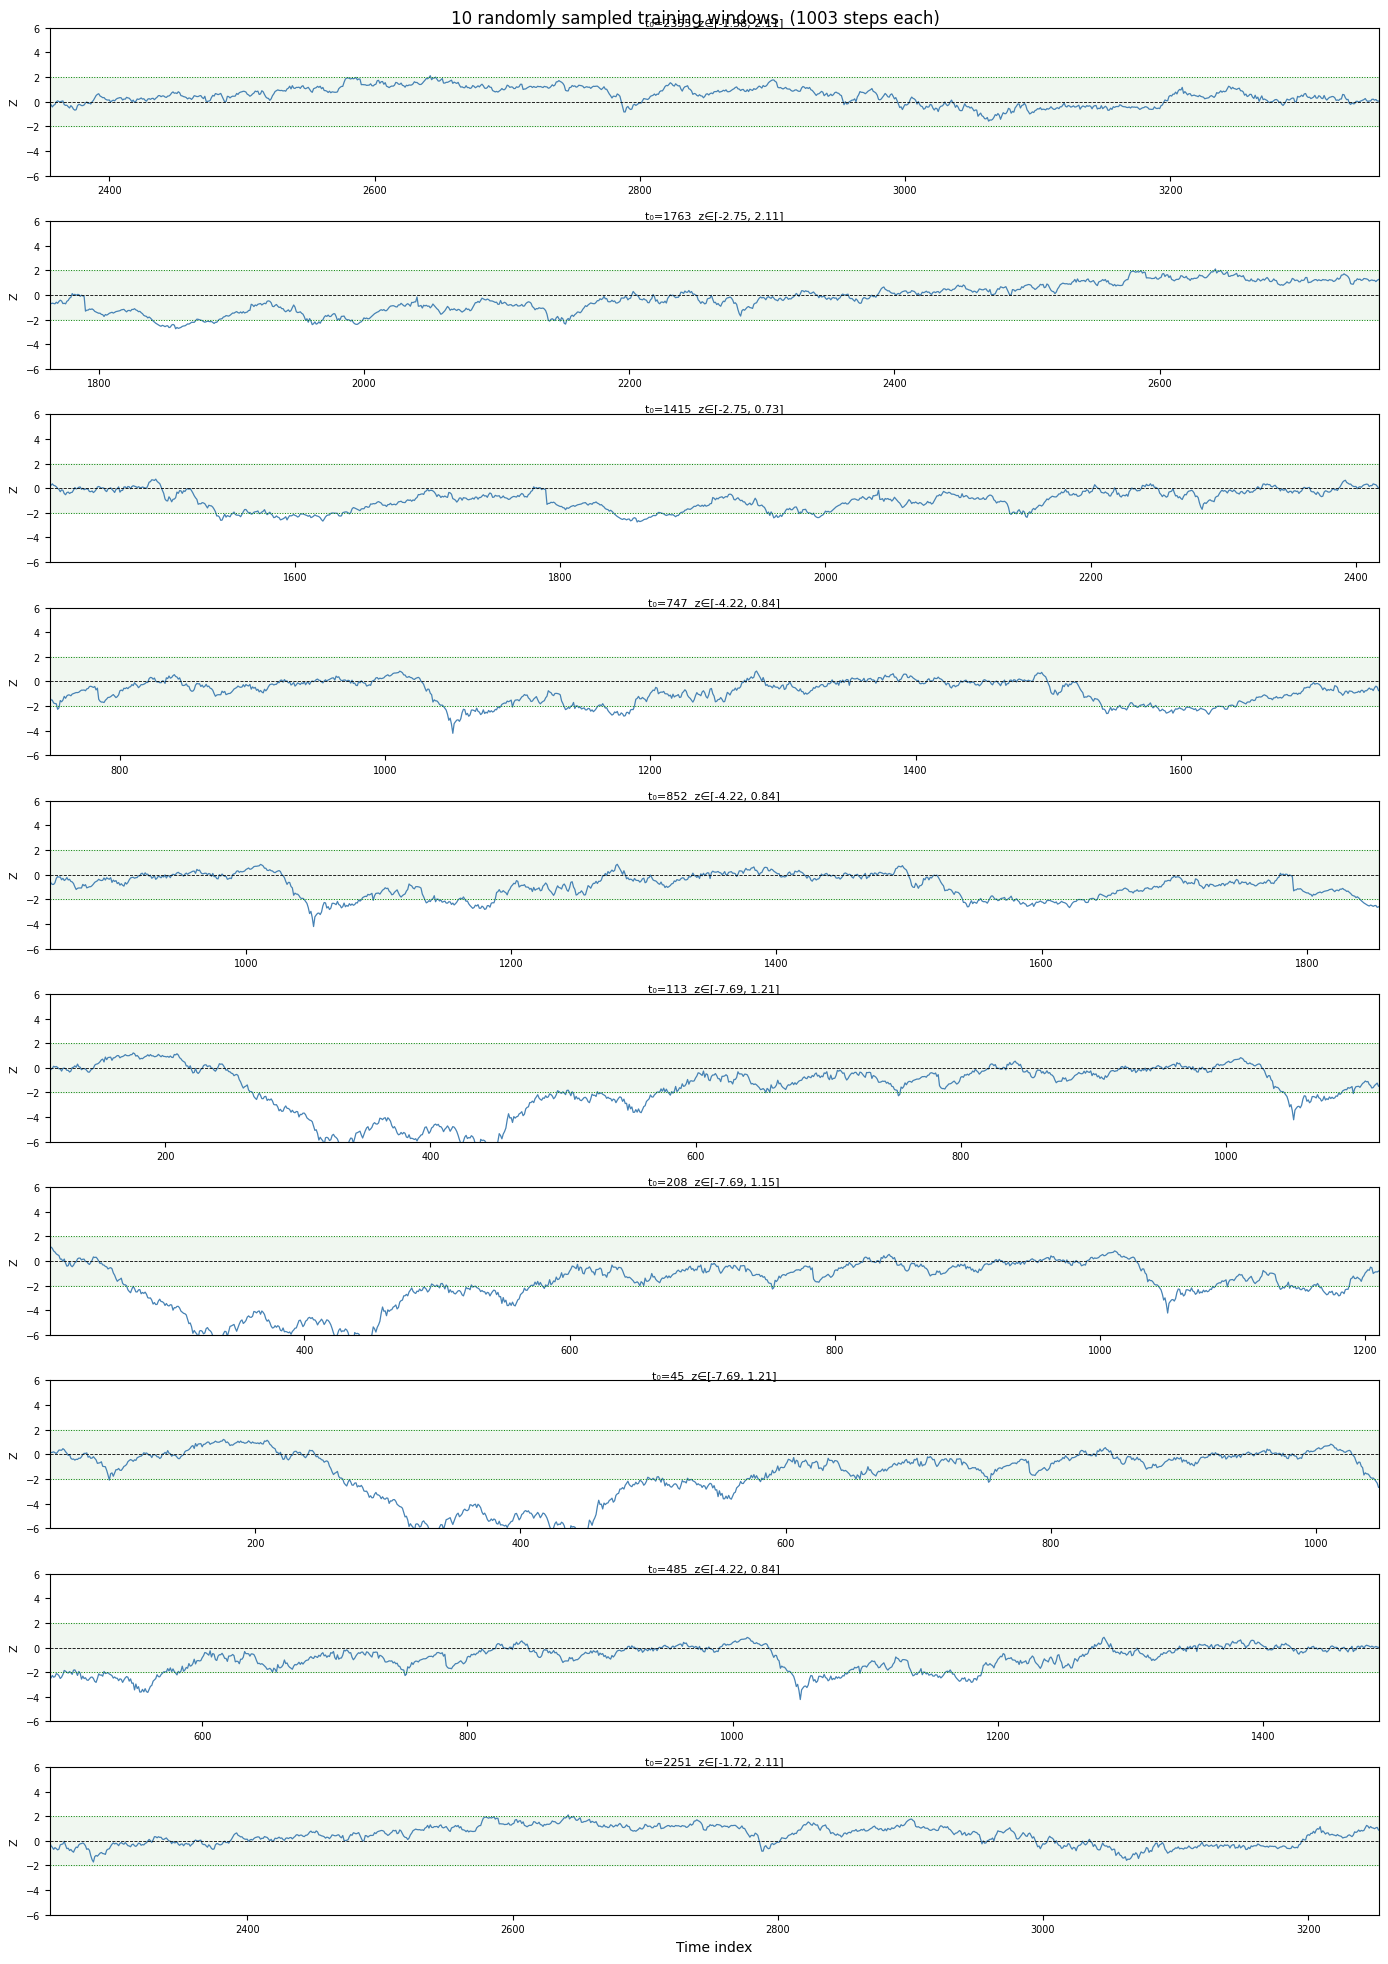

In [4]:
# ── Visualise 10 training windows (stacked) ──────────────────────────────
N_SHOW  = 10
rng_vis = np.random.default_rng(0)

z_full = (hist_spread - train_mean) / train_std   # full-series z (for plotting only)
# Note: z_full only computed on training portion; extend for plotting
spread_full = log_A - beta * log_B - intercept
z_full_all  = (spread_full - train_mean) / train_std

t0_list = [int(rng_vis.integers(0, REAL_T_MAX + 1)) for _ in range(N_SHOW)]

fig, axes = plt.subplots(N_SHOW, 1, figsize=(14, N_SHOW * 2.0), sharex=False)
fig.suptitle(f'{N_SHOW} randomly sampled training windows  ({EP_LEN_FULL} steps each)', fontsize=12)

for ax, t0 in zip(axes, t0_list):
    t_end = t0 + EP_LEN_FULL
    t_idx = np.arange(t0, t_end)
    z_ep  = z_full_all[t0:t_end]

    ax.plot(t_idx, z_ep, color='steelblue', lw=0.9)
    ax.fill_between(t_idx, -2, 2, alpha=0.06, color='green')
    ax.axhline( 0,   color='black', lw=0.6, ls='--')
    ax.axhline( 2.0, color='green', lw=0.7, ls=':')
    ax.axhline(-2.0, color='green', lw=0.7, ls=':')
    ax.set_xlim(t0, t_end - 1)
    ax.set_ylim(-6, 6)
    ax.set_ylabel('Z', fontsize=8)
    ax.set_title(f't₀={t0}  z∈[{z_ep.min():.2f}, {z_ep.max():.2f}]', fontsize=8, pad=2)
    ax.tick_params(labelsize=7)

axes[-1].set_xlabel('Time index')
plt.tight_layout()
plt.show()

In [5]:
# ── Agent ─────────────────────────────────────────────────────────────────
agent = DoubleDQN(
    state_dim       = 4,
    action_dim      = 3,
    hidden          = 64,
    lr              = 3e-4,
    gamma           = 0.99,
    tau             = 0.005,
    buffer_size     = int(1e6),
    batch_size      = 256,
    eps_start       = 1.0,
    eps_end         = 0.05,
    eps_decay_steps = 600_000,
    grad_clip       = 1.0,
)
print(f'Agent ready.  Initial epsilon: {agent.epsilon:.3f}')

Agent ready.  Initial epsilon: 1.000


In [6]:
# ── Training loop — real data only ────────────────────────────────────────
N_EPISODES  = 1200
TRAIN_FREQ  = 4
LOG_EVERY   = 100

ep_rewards  = []
ep_wealth   = []
ep_eps      = []
losses      = []
total_steps = 0

# tc=0.004: commodity transaction costs are much higher than equities
env_kw = dict(beta=beta, intercept=intercept, z_mean=train_mean, z_std=train_std,
              episode_len=EPISODE_LEN, tc=0.004)

for ep in range(N_EPISODES):
    t0        = int(rng.integers(0, REAL_T_MAX + 1))
    prices_ep = sample_real(t0)
    env       = PairTradingEnv(prices_ep, **env_kw)

    obs, _ = env.reset()
    done   = False
    ep_r   = 0.0

    while not done:
        action = agent.select_action(obs)
        next_obs, reward, done, _, _ = env.step(action)
        agent.replay_buffer.add(obs, action, reward, next_obs, done)
        obs  = next_obs
        ep_r += reward
        total_steps += 1

        if total_steps % TRAIN_FREQ == 0:
            loss = agent.train()
            if loss is not None:
                losses.append(loss)

    ep_rewards.append(ep_r)
    ep_wealth.append(env._wealth())
    ep_eps.append(agent.epsilon)

    if (ep + 1) % LOG_EVERY == 0:
        avg_r = np.mean(ep_rewards[-LOG_EVERY:])
        avg_w = np.mean(ep_wealth[-LOG_EVERY:])
        print(f'ep {ep+1:5d} | avg_reward {avg_r:+8.2f} | avg_wealth {avg_w:8.2f} | '
              f'eps {agent.epsilon:.3f}')

ep   100 | avg_reward -9580.54 | avg_wealth   419.46 | eps 0.842
ep   200 | avg_reward -9383.73 | avg_wealth   616.27 | eps 0.683
ep   300 | avg_reward -9052.50 | avg_wealth   947.50 | eps 0.525
ep   400 | avg_reward -8170.05 | avg_wealth  1829.95 | eps 0.367
ep   500 | avg_reward -6171.02 | avg_wealth  3828.98 | eps 0.208
ep   600 | avg_reward -1663.85 | avg_wealth  8336.15 | eps 0.050
ep   700 | avg_reward +1522.34 | avg_wealth 11522.34 | eps 0.050
ep   800 | avg_reward +2208.81 | avg_wealth 12208.81 | eps 0.050
ep   900 | avg_reward +1629.22 | avg_wealth 11629.22 | eps 0.050
ep  1000 | avg_reward +2269.09 | avg_wealth 12269.09 | eps 0.050
ep  1100 | avg_reward +2813.36 | avg_wealth 12813.36 | eps 0.050
ep  1200 | avg_reward +4606.18 | avg_wealth 14606.18 | eps 0.050


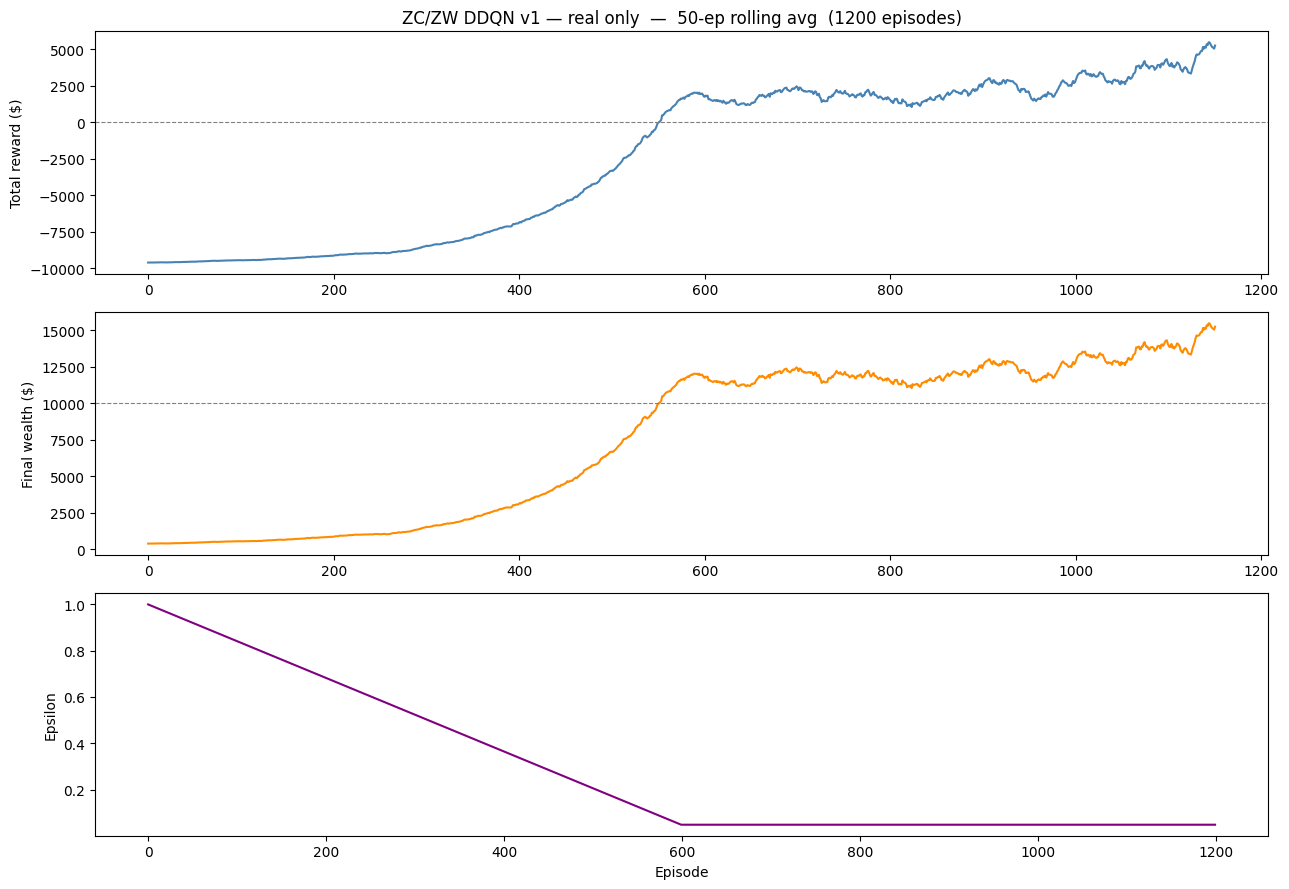

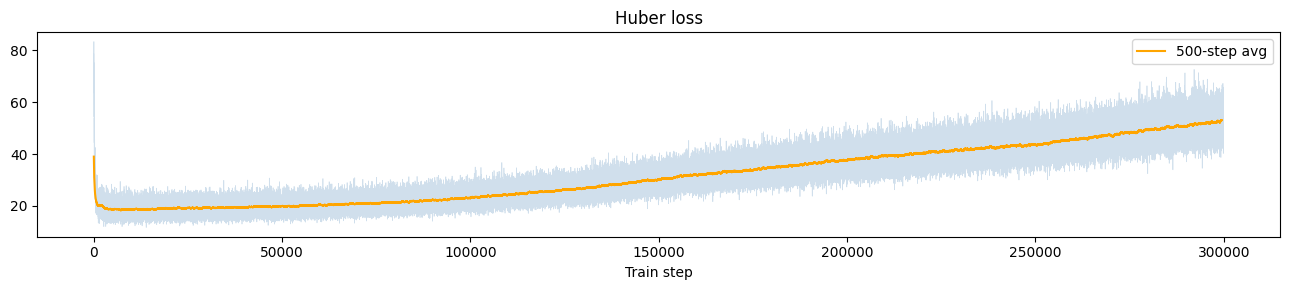

In [7]:
# ── Training curves ──────────────────────────────────────────────────────
roll = 50
kern = np.ones(roll) / roll

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=False)

axes[0].plot(np.convolve(ep_rewards, kern, mode='valid'), color='steelblue')
axes[0].axhline(0, color='gray', lw=0.8, ls='--')
axes[0].set_ylabel('Total reward ($)')
axes[0].set_title(f'ZC/ZW DDQN v1 — real only  —  {roll}-ep rolling avg  ({N_EPISODES} episodes)')

axes[1].plot(np.convolve(ep_wealth, kern, mode='valid'), color='darkorange')
axes[1].axhline(10_000, color='gray', lw=0.8, ls='--')
axes[1].set_ylabel('Final wealth ($)')

axes[2].plot(ep_eps, color='purple')
axes[2].set_ylabel('Epsilon')
axes[2].set_xlabel('Episode')

plt.tight_layout()
plt.show()

if losses:
    fig, ax = plt.subplots(figsize=(13, 3))
    ax.plot(losses, alpha=0.25, lw=0.5, color='steelblue')
    smooth = np.convolve(losses, np.ones(500)/500, mode='valid')
    ax.plot(smooth, color='orange', lw=1.5, label='500-step avg')
    ax.set_title('Huber loss')
    ax.set_xlabel('Train step')
    ax.legend()
    plt.tight_layout()
    plt.show()

In [8]:
# ── Evaluation helpers ───────────────────────────────────────────────────
_RF_DAILY = (1.05) ** (1.0 / 252) - 1

def evaluate(env, agent, t_start=None, t_end=None):
    if t_start is not None:
        env._t      = t_start
        env._end    = t_end if t_end is not None else env._N
        env._cash   = env.initial_wealth
        env._shares = np.zeros(2, dtype=np.float64)
        env._pos    = 0
        obs         = env._obs()
    else:
        obs, _ = env.reset()

    t0            = env._t
    wealth        = [env._wealth()]
    z_hist        = [float(obs[0])]
    pos_hist      = []
    entries_long  = []
    entries_short = []
    exits         = []
    step          = 0

    done = False
    while not done:
        prev_pos = env._pos
        action   = agent.select_action(obs, deterministic=True)
        obs, reward, done, _, _ = env.step(action)

        pos_hist.append(env._pos)
        wealth.append(env._wealth())
        z_hist.append(float(obs[0]))

        if env._pos != prev_pos:
            if env._pos == 1:
                entries_long.append(step)
            elif env._pos == -1:
                entries_short.append(step)
            else:
                exits.append(step)
        step += 1

    return {
        'wealth':        np.array(wealth),
        'z':             np.array(z_hist),
        'pos':           np.array(pos_hist),
        'entries_long':  entries_long,
        'entries_short': entries_short,
        'exits':         exits,
        't_start':       t0,
    }


def metrics(wealth, label=''):
    W   = np.array(wealth)
    ret = np.diff(W) / W[:-1]
    total_ret = (W[-1] / W[0] - 1.0) * 100
    sharpe    = ret.mean() / (ret.std() + 1e-10) * np.sqrt(252)
    peak      = np.maximum.accumulate(W)
    mdd       = ((W - peak) / peak).min() * 100
    print(f'{label:50s}  final ${W[-1]:8.0f}  ret {total_ret:+6.1f}%  Sharpe {sharpe:5.2f}  MDD {mdd:6.1f}%')
    return {'sharpe': sharpe, 'mdd': mdd, 'total_ret': total_ret}


def plot_results(res, title=''):
    t0      = res['t_start']
    steps   = len(res['z']) - 1
    t_idx   = np.arange(t0, t0 + steps + 1)
    t_idx_p = t_idx[t_idx < prices.shape[1]]

    W         = res['wealth']
    benchmark = W[0] * (1 + _RF_DAILY) ** np.arange(len(W))

    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
    fig.suptitle(title, fontsize=12)

    axes[0].plot(t_idx, W,         color='navy', label='strategy')
    axes[0].plot(t_idx, benchmark, color='gray', lw=1, ls='--', label='5% p.a.')
    axes[0].axhline(W[0], color='lightgray', lw=0.6, ls=':')
    axes[0].set_ylabel('Wealth ($)')
    axes[0].legend(fontsize=8)

    axes[1].plot(t_idx_p, prices[0, t_idx_p], label=data.labels[0], alpha=0.8)
    axes[1].plot(t_idx_p, prices[1, t_idx_p], label=data.labels[1], alpha=0.8)
    axes[1].legend(fontsize=8)
    axes[1].set_ylabel('Price ($)')

    ax_z = axes[2]
    ax_z.plot(t_idx, res['z'], color='black', lw=0.8)
    ax_z.axhline(0,    color='gray',  lw=0.8, ls='--')
    ax_z.axhline( 2.0, color='green', lw=0.8, ls=':')
    ax_z.axhline(-2.0, color='green', lw=0.8, ls=':')

    pos_ext = np.concatenate([[0], res['pos']])
    for i in range(len(pos_ext) - 1):
        if pos_ext[i] == 1:
            ax_z.axvspan(t_idx[i], t_idx[i+1], alpha=0.12, color='green')
        elif pos_ext[i] == -1:
            ax_z.axvspan(t_idx[i], t_idx[i+1], alpha=0.12, color='red')

    for i in res['entries_long']:
        ax_z.scatter(t_idx[i], res['z'][i], color='green', s=30, zorder=5)
    for i in res['entries_short']:
        ax_z.scatter(t_idx[i], res['z'][i], color='red',   s=30, zorder=5)
    for i in res['exits']:
        ax_z.scatter(t_idx[i], res['z'][i], color='blue',  s=15, zorder=5)

    n_l = len(res['entries_long']);  n_s = len(res['entries_short'])
    ax_z.set_ylabel('Z-score')
    ax_z.set_xlabel('Time index')
    ax_z.set_title(f'long: {n_l}  |  short: {n_s}  |  exits: {len(res["exits"])}')

    plt.tight_layout()
    plt.show()

=== Test set (Q4) ===
DDQN ZC/ZW v1 — test Q4                             final $   15999  ret  +60.0%  Sharpe  0.52  MDD  -50.4%


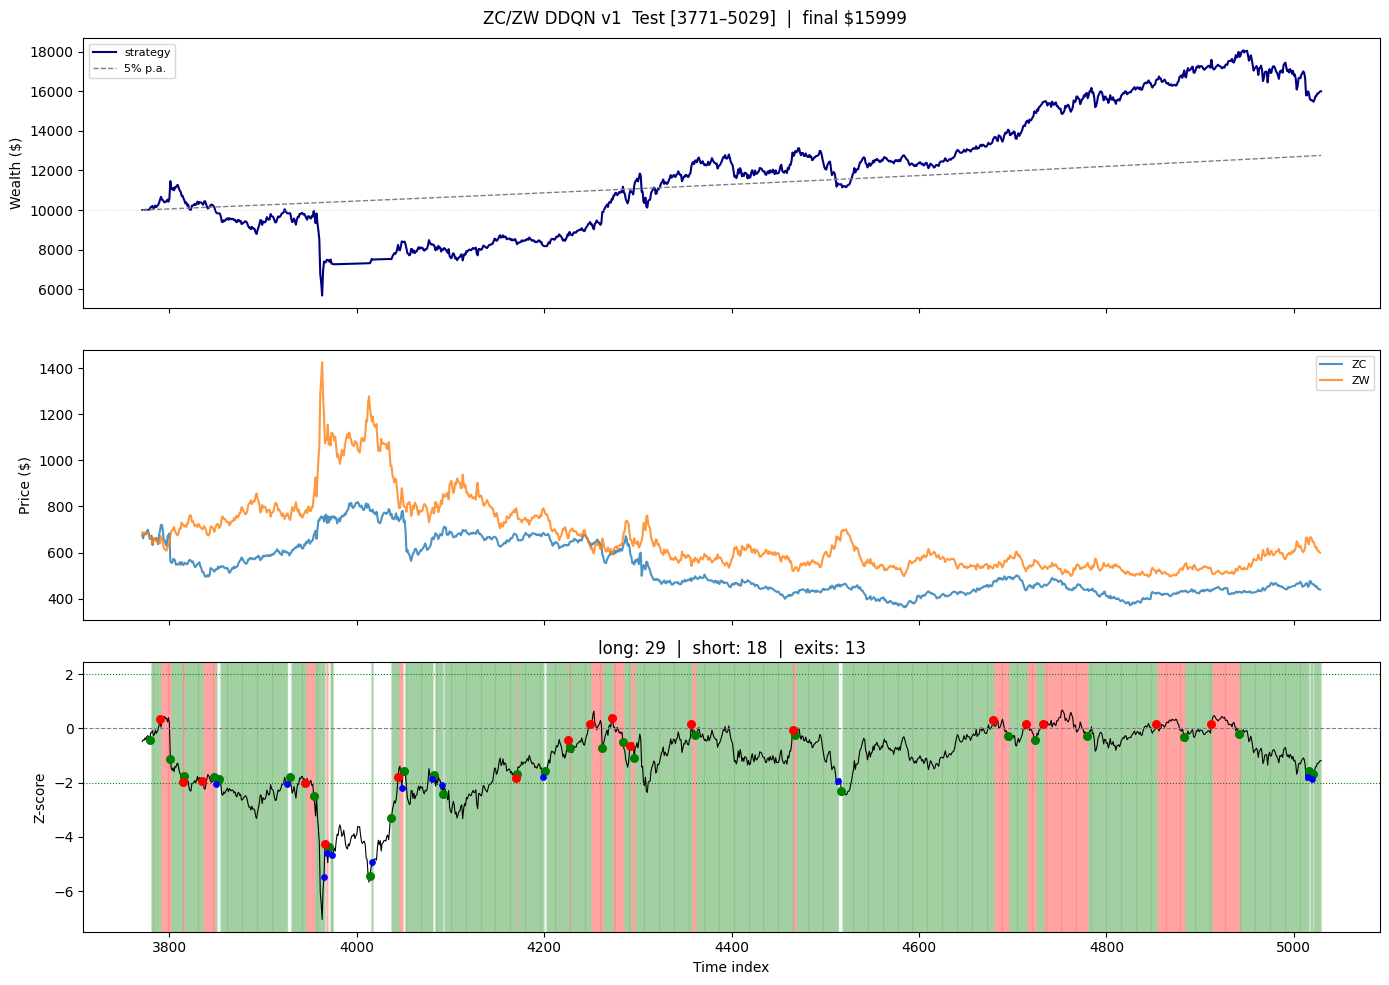

In [9]:
# ── Evaluation on real data ───────────────────────────────────────────────
real_env = PairTradingEnv(
    prices=prices, beta=beta, intercept=intercept,
    z_mean=train_mean, z_std=train_std, tc=0.004,
)

print('=== Test set (Q4) ===')
res_test = evaluate(real_env, agent, t_start=train_end, t_end=N)
m_test   = metrics(res_test['wealth'], 'DDQN ZC/ZW v1 — test Q4')
plot_results(res_test, title=f'ZC/ZW DDQN v1  Test [{train_end}–{N}]  |  final ${res_test["wealth"][-1]:.0f}')

=== Training windows ===
Train yr 1  [3–255]                                 final $   14047  ret  +40.5%  Sharpe  1.91  MDD  -16.4%


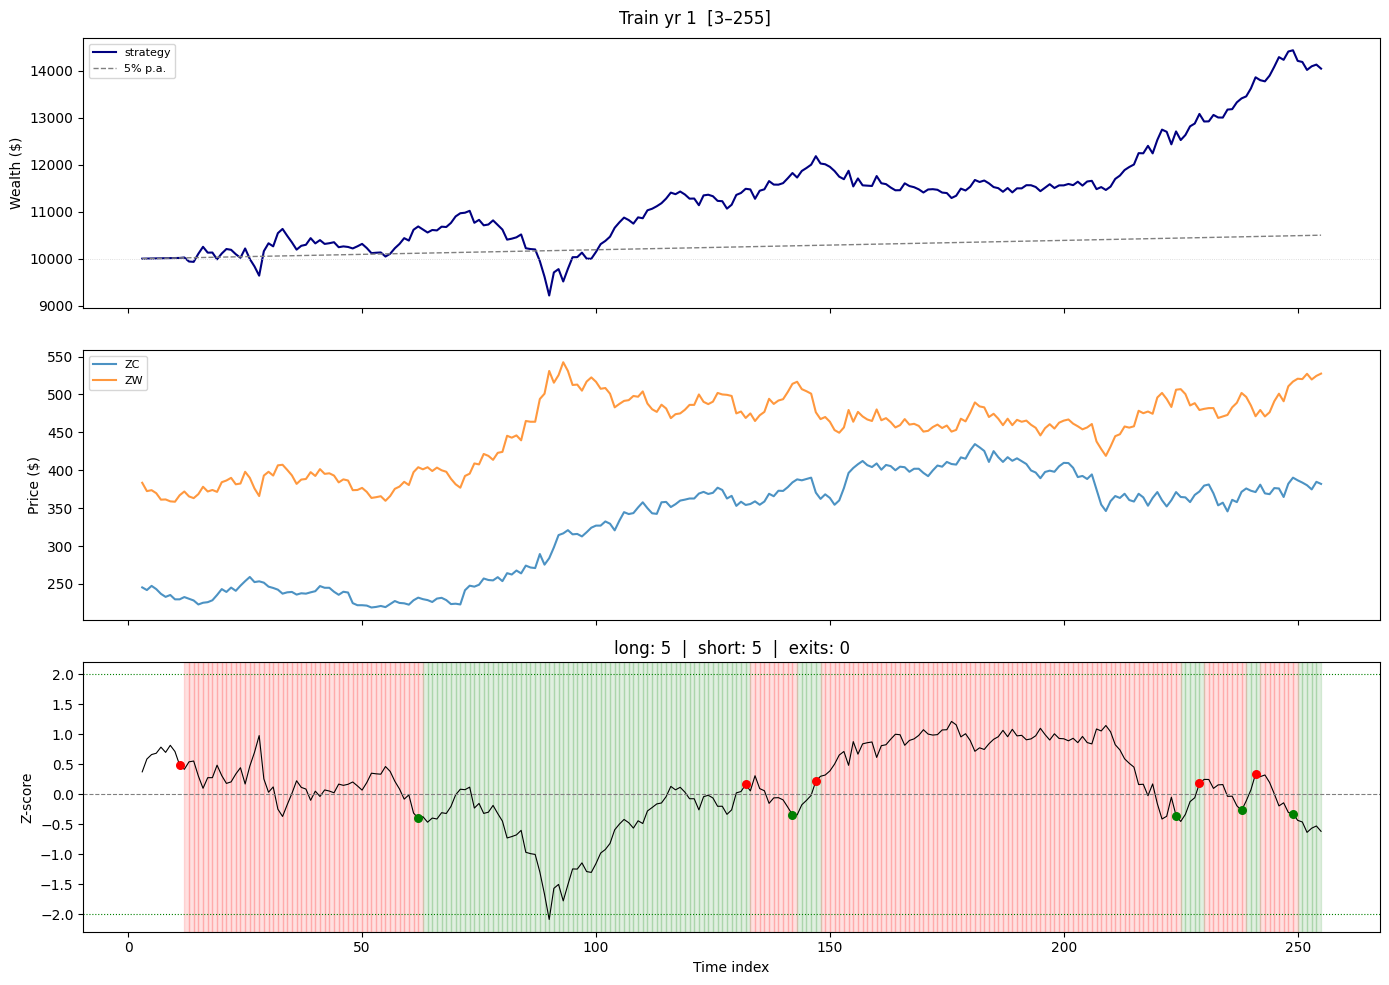

Train yr 2  [255–507]                               final $   11874  ret  +18.7%  Sharpe  1.02  MDD  -23.9%


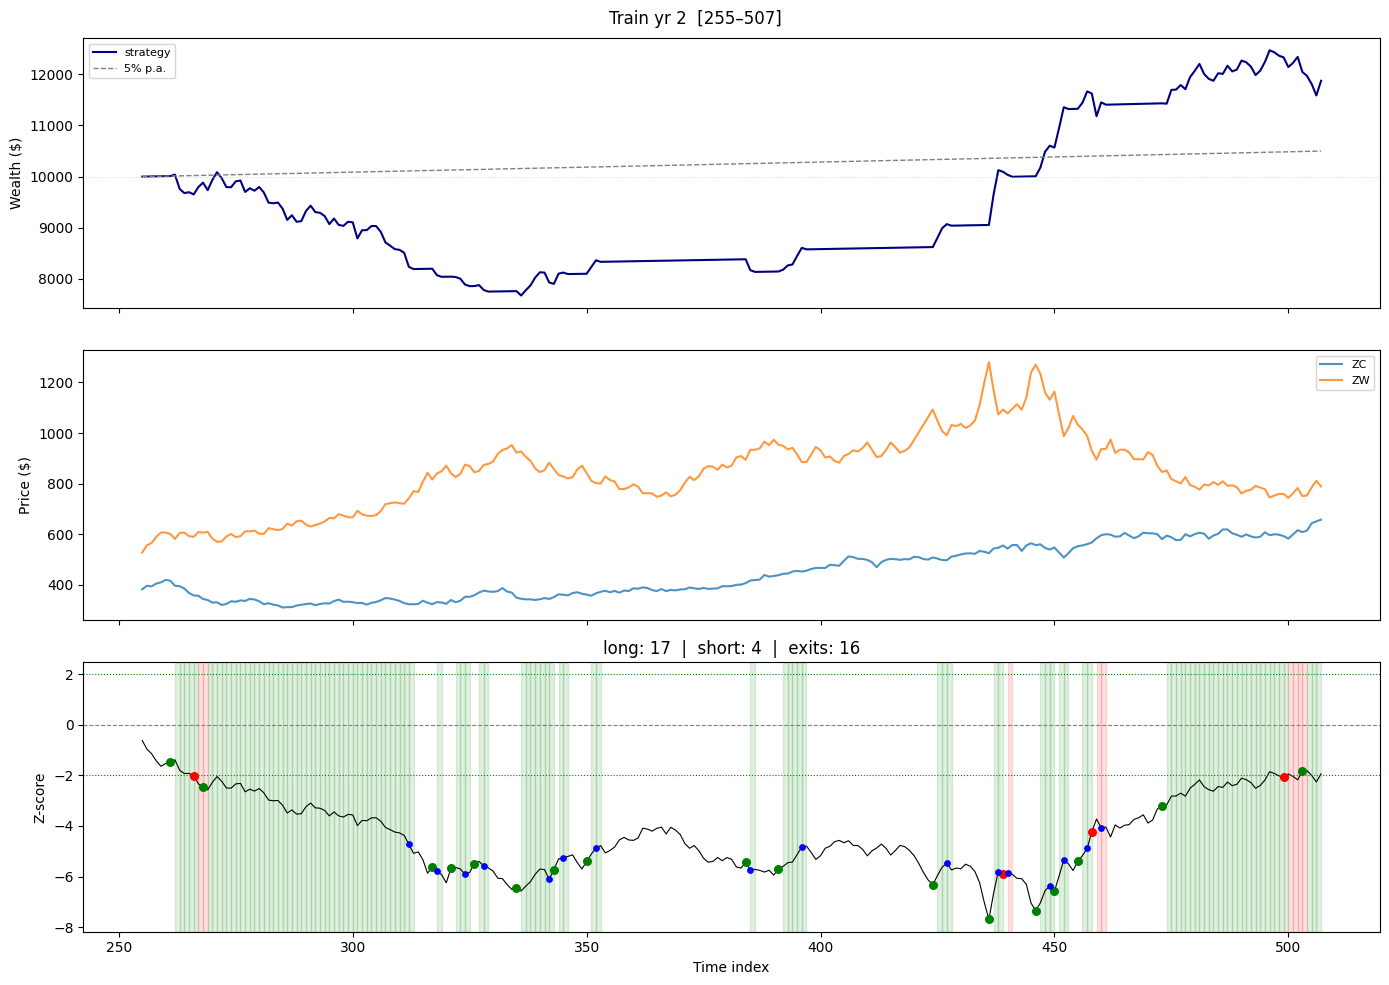

Train yr 3  [507–759]                               final $   10683  ret   +6.8%  Sharpe  0.41  MDD  -14.0%


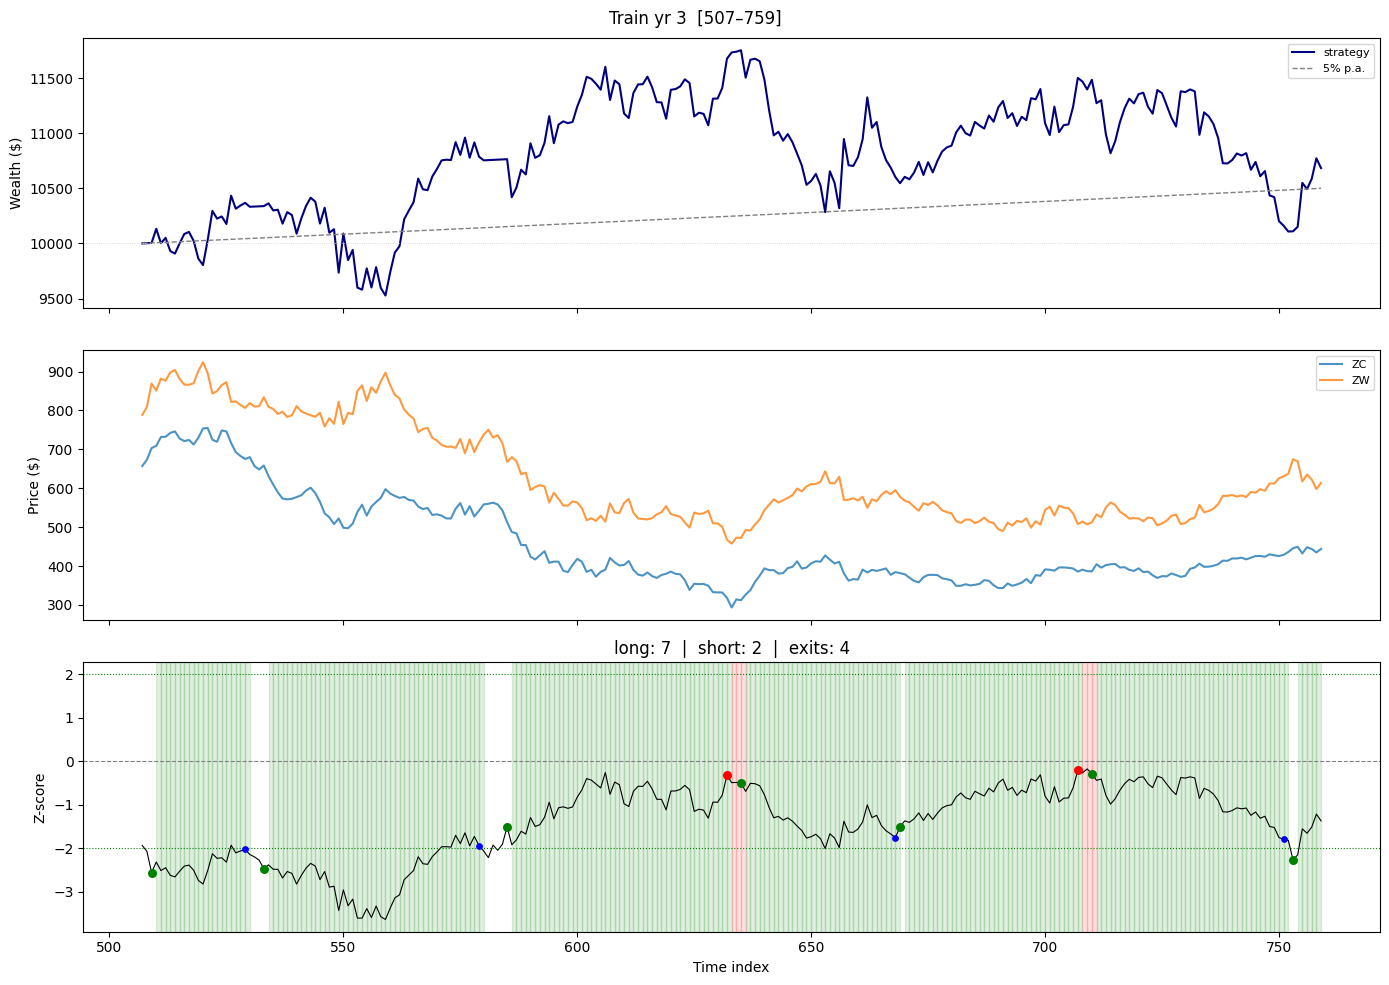

Train yr 4  [759–1011]                              final $   12741  ret  +27.4%  Sharpe  1.64  MDD   -6.8%


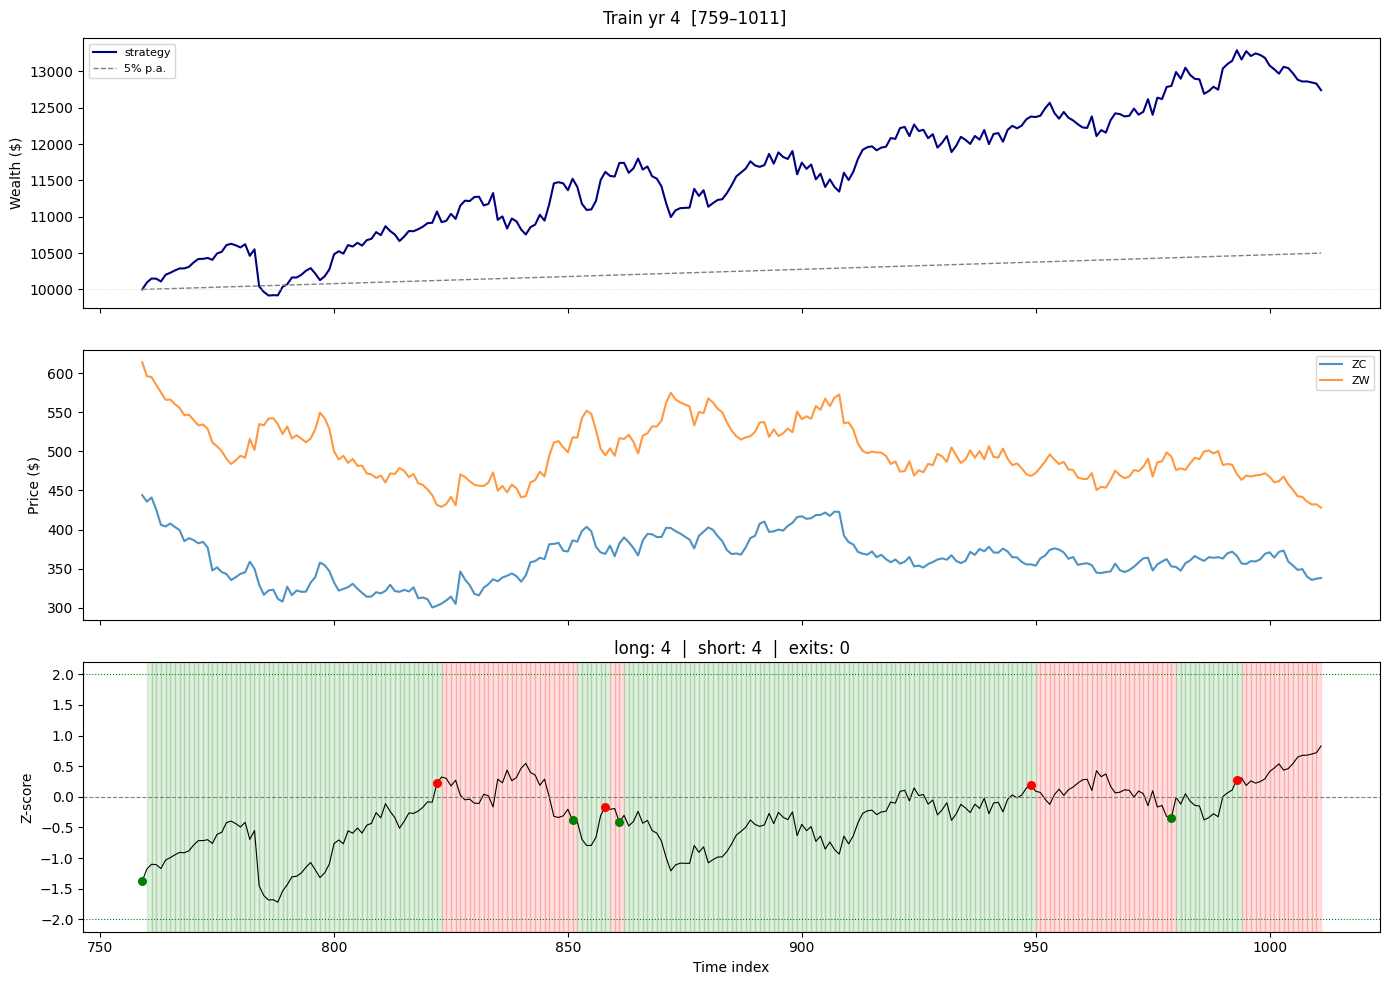

In [10]:
# ── Behaviour on training windows ────────────────────────────────────────
print('=== Training windows ===')
win = 252
for k in range(4):
    t0 = real_env._min_t + k * win
    t1 = t0 + win
    if t1 > train_end:
        break
    res_tr = evaluate(real_env, agent, t_start=t0, t_end=t1)
    label  = f'Train yr {k+1}  [{t0}–{t1}]'
    metrics(res_tr['wealth'], label)
    plot_results(res_tr, title=label)

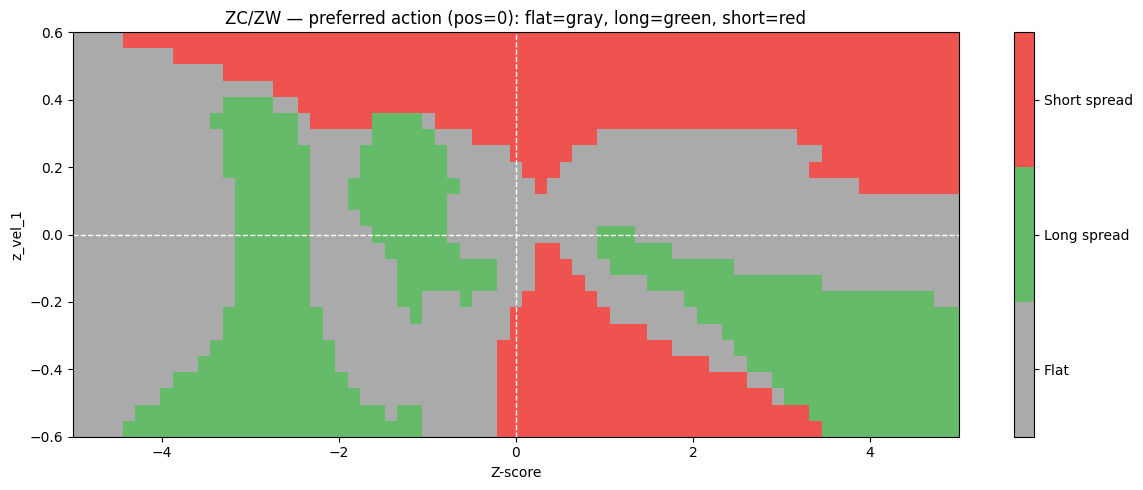

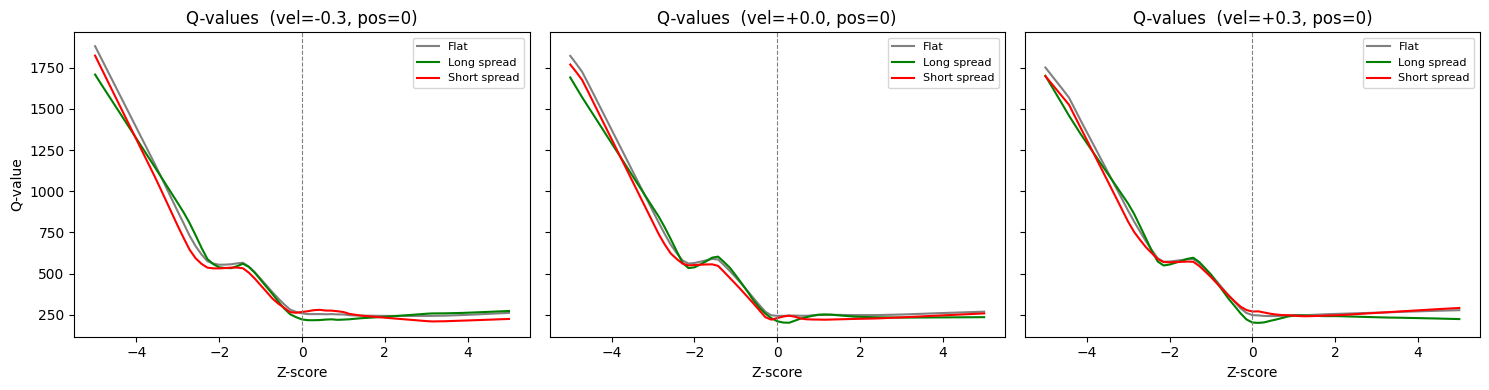

In [11]:
# ── Network interpretation ────────────────────────────────────────────────
ACT_LABELS = ['Flat', 'Long spread', 'Short spread']
ACT_COLORS = ['gray', 'green', 'red']

z_vals   = np.linspace(-5, 5, 71)     # ZC/ZW spread can be more extreme
vel_vals = np.linspace(-0.6, 0.6, 25)

agent.q_net.eval()
action_grid = np.zeros((len(vel_vals), len(z_vals)), dtype=int)

with torch.no_grad():
    for i, v in enumerate(vel_vals):
        for j, z in enumerate(z_vals):
            obs = np.array([z, 0.0, v, v * 2.0], dtype=np.float32)
            s   = torch.from_numpy(obs).unsqueeze(0)
            action_grid[i, j] = int(agent.q_net(s).argmax().item())

agent.q_net.train()

cmap = plt.matplotlib.colors.ListedColormap(['#aaaaaa', '#66bb6a', '#ef5350'])
fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(
    action_grid, aspect='auto', origin='lower', cmap=cmap, vmin=-0.5, vmax=2.5,
    extent=[z_vals[0], z_vals[-1], vel_vals[0], vel_vals[-1]],
)
ax.set_xlabel('Z-score')
ax.set_ylabel('z_vel_1')
ax.set_title('ZC/ZW — preferred action (pos=0): flat=gray, long=green, short=red')
ax.axvline(0, color='white', lw=1, ls='--')
ax.axhline(0, color='white', lw=1, ls='--')
cbar = plt.colorbar(im, ax=ax, ticks=[0, 1, 2])
cbar.set_ticklabels(ACT_LABELS)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, v_fix in zip(axes, [-0.3, 0.0, 0.3]):
    q_vals = np.zeros((len(z_vals), 3))
    with torch.no_grad():
        for j, z in enumerate(z_vals):
            obs = np.array([z, 0.0, v_fix, v_fix * 2.0], dtype=np.float32)
            s   = torch.from_numpy(obs).unsqueeze(0)
            q_vals[j] = agent.q_net(s).numpy()[0]
    for k, (lbl, col) in enumerate(zip(ACT_LABELS, ACT_COLORS)):
        ax.plot(z_vals, q_vals[:, k], label=lbl, color=col, lw=1.5)
    ax.axvline(0, color='gray', lw=0.8, ls='--')
    ax.set_xlabel('Z-score')
    ax.set_title(f'Q-values  (vel={v_fix:+.1f}, pos=0)')
    ax.legend(fontsize=8)
axes[0].set_ylabel('Q-value')
plt.tight_layout()
plt.show()

In [12]:
import os
os.makedirs('../models', exist_ok=True)
agent.save('../models/zc_zw_ddqn_v1.pt')
print('Model saved.')

Model saved.
